---
title: "Neuron Skeletons"
format: 
    html:
        toc: true 
        code-fold: false
jupyter: python3
---

## Download, visualize, and generate neuron skeletons

Created 7/2/2024 by Bethanny Danskin  
MICrONS Tutorial for VORTEX

Depends on the following two packages: [CAVEclient](https://caveconnectome.github.io/CAVEclient/) and [Skeleton-Plot](https://github.com/AllenInstitute/skeleton_plot) (version>0.0.9)

Skeletons and meshworks are loaded as [MeshParty meshwork object](https://meshparty.readthedocs.io/en/latest/)

[pcg-skel](https://github.com/CAVEconnectome/pcg_skel) and [cloudvolume](https://github.com/seung-lab/cloud-volume) are necessary if generating your own skeletons from the meshes

:::{important}
Using `CAVEclient` requires having set up a CAVE auth token. 
See [how to set up your CAVEclient token here](em_py_01_caveclient_setup.html).
:::

In [1]:
# !pip install caveclient
# !pip install skeleton-plot

In [4]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from datetime import datetime

import skeleton_plot as sklpt
import skeleton_plot.skel_io as skio

In [5]:
from caveclient import CAVEclient

client = CAVEclient()
client.auth.save_token(token="26091ee0f1db6f49bbf212ef6e5dcac9", overwrite=True)

In [6]:
# Initialize a client for the "minnie65_public" datastack.
client = CAVEclient(datastack_name='minnie65_public') 

# see the available materialization versions
client.materialize.get_versions()

# Uncomment to get more details on each release version
# client.materialize.get_versions_metadata()

[1300, 1078, 117, 661, 343, 1181, 795, 943, 1412, 1507]

In [7]:
# set materialization version, for consistency
materialization = 1078 # current public as of 6/5/2024
# materialization = 661 # version at which skeletons were pre-generated
client.version = materialization

In [8]:
client.info.get_datastack_info()

{'aligned_volume': {'id': 1,
  'name': 'minnie65_phase3',
  'display_name': 'Minnie65',
  'description': "This is the second alignment of the IARPA 'minnie65' dataset, completed in the spring of 2020 that used the seamless approach.",
  'image_source': 'precomputed://https://bossdb-open-data.s3.amazonaws.com/iarpa_microns/minnie/minnie65/em'},
 'segmentation_source': 'graphene://https://minnie.microns-daf.com/segmentation/table/minnie65_public',
 'skeleton_source': 'precomputed://middleauth+https://minnie.microns-daf.com/skeletoncache/api/v1/minnie65_public/precomputed/skeleton/',
 'analysis_database': None,
 'viewer_site': 'https://spelunker.cave-explorer.org/',
 'synapse_table': 'synapses_pni_2',
 'soma_table': 'nucleus_detection_v0',
 'local_server': 'https://minnie.microns-daf.com',
 'description': 'This is the publicly released version of the minnie65 volume and segmentation. ',
 'viewer_resolution_x': 4.0,
 'viewer_resolution_y': 4.0,
 'viewer_resolution_z': 40.0,
 'proofreading_

In [9]:
client.materialize.get_tables() # list available tables

['proofreading_status_and_strategy',
 'synapse_target_structure',
 'aibs_metamodel_celltypes_v661',
 'nucleus_alternative_points',
 'allen_column_mtypes_v2',
 'bodor_pt_cells',
 'aibs_metamodel_mtypes_v661_v2',
 'allen_v1_column_types_slanted_ref',
 'aibs_column_nonneuronal_ref',
 'nucleus_ref_neuron_svm',
 'apl_functional_coreg_vess_fwd',
 'vortex_compartment_targets',
 'baylor_log_reg_cell_type_coarse_v1',
 'functional_properties_v3_bcm',
 'l5et_column',
 'pt_synapse_targets',
 'proofreading_status_public_release',
 'coregistration_auto_phase3_fwd_apl_vess_combined',
 'coregistration_manual_v4',
 'nucleus_neuron_svm',
 'coregistration_manual_v3',
 'vortex_manual_myelination_v0',
 'synapses_pni_2',
 'nucleus_detection_v0',
 'vortex_manual_nodes_of_ranvier',
 'bodor_pt_target_proofread',
 'vortex_astrocyte_proofreading_status',
 'nucleus_functional_area_assignment',
 'coregistration_auto_phase3_fwd']

In [10]:
# get class labels table
class_table = client.materialize.tables.allen_v1_column_types_slanted_ref().query(materialization_version=1078)

### Set paths to the public repository

The skeletons of the meshes are calculated at specific timepoints. The last collection of all neurons in the dataset was at materialization version 661.

Both the .swc skeletons and .h5 meshwork objects are available in the [BossDB repository](https://bossdb.org/project/microns-minnie)

In [11]:
# path to the skeleton .swc files
skel_path = "s3://bossdb-open-data/iarpa_microns/minnie/minnie65/skeletons/v661/skeletons/"

# path to the skeleton and meshwork .h5 files
mesh_path = "s3://bossdb-open-data/iarpa_microns/minnie/minnie65/skeletons/v661/meshworks/"

In [25]:
import s3fs

fs = s3fs.S3FileSystem(anon=True)
# list all skeleton files
skel_files = fs.ls(skel_path)
print(f"Found {len(skel_files)} skeleton files")

Found 76980 skeleton files


### Example: load cell with known nucleus id and segment id

In [34]:
# Skeleton
nucleus_id = 292685
segment_id = 864691135122603047
skel_filename = f"{segment_id}_{nucleus_id}.swc"

# load the .swc skeleton
sk = skio.read_skeleton(skel_path, skel_filename)

In [48]:
import random
# add different seed for different random skeleton
random.seed(2)  # Set a random seed for reproducibility
# Pick a random skeleton file from the list
random_skel_filename = random.choice(skel_files)
print(f"Random skeleton file: {random_skel_filename}")

# Extract just the filename (if needed)
random_skel_filename = random_skel_filename.split('/')[-1]

# Load the random skeleton
sk = skio.read_skeleton(skel_path, random_skel_filename)
print(f"Loaded skeleton: {random_skel_filename}")

Random skeleton file: bossdb-open-data/iarpa_microns/minnie/minnie65/skeletons/v661/skeletons/864691135250830511_765455.swc
Loaded skeleton: 864691135250830511_765455.swc


In [49]:
# List all attributes and methods of the Skeleton object
print("Attributes and methods of the Skeleton object:")
print(dir(sk))

# Inspect key properties of the Skeleton object
print("\nKey properties of the Skeleton object:")
print(f"Root: {sk.root}")
print(f"Vertices shape: {sk.vertices.shape}")
print(f"Edges shape: {sk.edges.shape}")
print(f"Branch points: {len(sk.branch_points)}")
print(f"End points: {len(sk.end_points)}")
print(f"Segments: {len(sk.segments)}")
print(f"Segments plus: {len(sk.segments_plus)}")
print(f"Path length: {sk.path_length(sk.segments[0])} nm (example segment)")


Attributes and methods of the Skeleton object:
['SkeletonIndex', '_SkeletonIndex', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_branch_points', '_compute_cover_paths', '_compute_segments', '_cover_paths', '_create_branch_and_end_points', '_create_default_root', '_csgraph_filtered', '_edges', '_end_points', '_kdtree', '_meta', '_node_mask', '_pykdtree', '_register_skeleton_index', '_reset_derived_properties_filtered', '_reset_derived_properties_rooted', '_rooted', '_segment_map', '_segments', '_single_path_length', '_vertices', 'apply_mask', 'branch_points', 'branch_points_undirected', 'child_nodes', 'copy', 'cover_paths', 'cover_pa

In [50]:
# Select the indices associated with the dendrites
dendrite_inds = (sk.vertex_properties['compartment']==3) | (sk.vertex_properties['compartment']==4)| (sk.vertex_properties['compartment']==1) #soma is included here to connect the dendrite graphs 
# create new skeleton that masks (selects) only the dendrite indices
sk_dendrite = sk.apply_mask(dendrite_inds)

In [45]:
# Minimal dependencies
import numpy as np
import networkx as nx

def build_branch_graph(skel_or_meshwork, include_root=True, include_tips=False):
    """
    Reduce a meshparty skeleton to its branching topology.

    Parameters
    ----------
    skel_or_meshwork : meshparty.skeleton.Skeleton or meshparty.meshwork.Meshwork
        Either the Skeleton directly (nrn.skeleton) or a Meshwork (nrn).
    include_root : bool
        Include the soma/root as a topological node.
    include_tips : bool
        If True, include end points (tips) as topo nodes; otherwise only branch points (+ root).

    Returns
    -------
    G : networkx.Graph
        Nodes are skeleton-vertex indices of the selected topo points.
        Node attrs:
            - pos: (x,y,z) coordinates (same units as the skeleton, typically nm)
            - kind: 'branch' | 'root' | 'tip'
        Edge attrs:
            - length_nm: path length along the original skeleton between the two topo nodes
            - n_vertices: number of skeleton vertices along that segment/path
            - path: numpy array of the skeleton-vertex indices comprising the segment
    """
    # Accept either a Meshwork or a Skeleton
    sk = getattr(skel_or_meshwork, "skeleton", skel_or_meshwork)

    # --- Choose which topological points to keep
    topo = set(sk.branch_points)  # branch points
    if include_root and sk.root is not None:
        topo.add(int(sk.root))
    if include_tips:
        topo.update(sk.end_points)

    topo = np.array(sorted(topo), dtype=int)

    # --- Build the reduced graph by walking segments between topo nodes
    # Use segments_plus so each segment includes the parent/topo node on the rootward end.
    # (segments are defined from a branch-or-tip to the next rootward branch/root) 
    G = nx.Graph()

    # Add nodes with attributes
    for v in topo:
        kind = "branch"
        if include_root and v == sk.root:
            kind = "root"
        elif include_tips and v in set(sk.end_points.tolist()):
            kind = "tip"
        G.add_node(int(v), pos=tuple(sk.vertices[v]), kind=kind)

    # Traverse segments and keep only those whose endpoints are both selected topo nodes
    for seg in sk.segments_plus:
        u, v = int(seg[0]), int(seg[-1])  # distal topo node -> rootward topo node
        if u in G and v in G and u != v:
            # Length along the original skeleton path
            length = float(sk.path_length(seg))
            G.add_edge(u, v, length_nm=length, n_vertices=len(seg), path=seg.copy())

    # Optional: keep only the connected component containing the root (if present)
    if include_root and sk.root in G:
        cc = max(nx.connected_components(G), key=len)  # largest CC (usually the soma tree)
        if sk.root not in cc:
            # fall back to the component with the root explicitly
            for c in nx.connected_components(G):
                if sk.root in c:
                    cc = c
                    break
        G = G.subgraph(cc).copy()

    return G

In [51]:
# Branch-only topology (root included, tips excluded)
G = build_branch_graph(sk_dendrite, include_root=True, include_tips=True)

print(f"Branch nodes: {G.number_of_nodes()}, branch edges: {G.number_of_edges()}")
# Inspect one edge
u, v, data = next(iter(G.edges(data=True)))
print("Example edge:", u, "->", v, "length (µm) =", data["length_nm"]/1_000)

Branch nodes: 15, branch edges: 14
Example edge: 0 -> 16 length (µm) = 0.028550148010253906


In [52]:
# Find all nodes in G
high_degree_nodes = [node for node in G.nodes() if G.degree(node) > 3]
print("Nodes with degree > 3:", high_degree_nodes)

Nodes with degree > 3: [0]


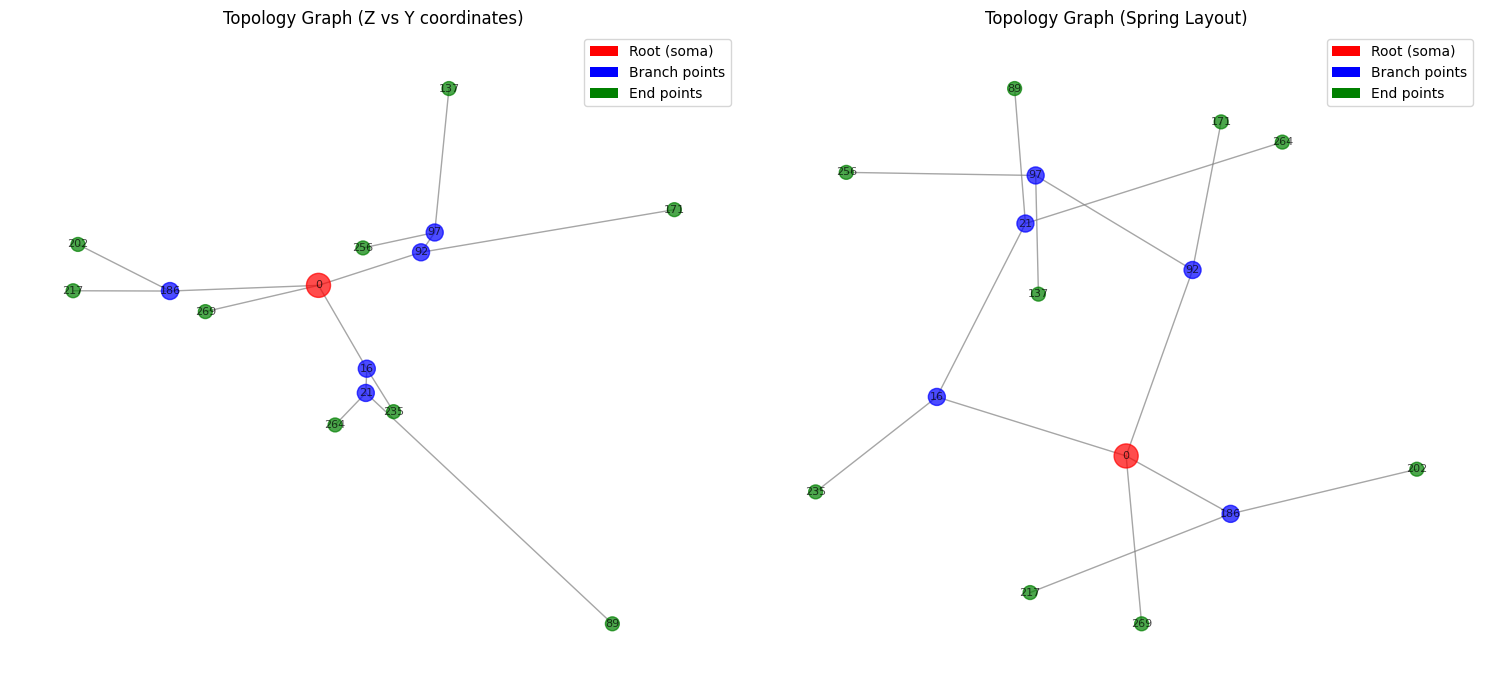

Topology Graph Statistics:
  Nodes: 15
  Edges: 14
  Root nodes: 1
  Branch nodes: 5
  Tip nodes: 9

Edge Lengths (µm):
  Mean: 0.0
  Min: 0.0
  Max: 0.1
  Total length: 0.4 µm


In [53]:
import matplotlib.pyplot as plt
import networkx as nx

# Plot the topology graph
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# Plot 1: 3D positions projected to 2D (z vs y)
pos_3d = {}
node_colors = []
node_sizes = []

for node in G.nodes():
    pos_3d[node] = (G.nodes[node]['pos'][2], G.nodes[node]['pos'][1])  # z, y coordinates
    
    # Color nodes by type
    if G.nodes[node]['kind'] == 'root':
        node_colors.append('red')
        node_sizes.append(300)
    elif G.nodes[node]['kind'] == 'branch':
        node_colors.append('blue')
        node_sizes.append(150)
    elif G.nodes[node]['kind'] == 'tip':
        node_colors.append('green')
        node_sizes.append(100)

# Draw the graph with 3D positions
nx.draw(G, pos_3d, ax=ax1, 
        node_color=node_colors, 
        node_size=node_sizes,
        with_labels=True, 
        font_size=8,
        edge_color='gray',
        alpha=0.7)

ax1.set_title('Topology Graph (Z vs Y coordinates)')
ax1.set_xlabel('Z (nm)')
ax1.set_ylabel('Y (nm)')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='Root (soma)'),
                   Patch(facecolor='blue', label='Branch points'),
                   Patch(facecolor='green', label='End points')]
ax1.legend(handles=legend_elements, loc='upper right')

# Plot 2: Spring layout for better topology visualization
pos_spring = nx.spring_layout(G, k=1, iterations=50)

nx.draw(G, pos_spring, ax=ax2,
        node_color=node_colors,
        node_size=node_sizes,
        with_labels=True,
        font_size=8,
        edge_color='gray',
        alpha=0.7)

ax2.set_title('Topology Graph (Spring Layout)')
ax2.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Print some statistics about the topology
print(f"Topology Graph Statistics:")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
print(f"  Root nodes: {sum(1 for n in G.nodes() if G.nodes[n]['kind'] == 'root')}")
print(f"  Branch nodes: {sum(1 for n in G.nodes() if G.nodes[n]['kind'] == 'branch')}")
print(f"  Tip nodes: {sum(1 for n in G.nodes() if G.nodes[n]['kind'] == 'tip')}")

# Show edge lengths
edge_lengths = [data['length_nm']/1000 for u, v, data in G.edges(data=True)]  # Convert to micrometers
print(f"\nEdge Lengths (µm):")
print(f"  Mean: {np.mean(edge_lengths):.1f}")
print(f"  Min: {np.min(edge_lengths):.1f}")
print(f"  Max: {np.max(edge_lengths):.1f}")
print(f"  Total length: {np.sum(edge_lengths):.1f} µm")

#### Reduction 

Basic cherry rake reduction algorithm for binary trees applied on dendrites.

In [72]:
# WORKING VERSION: Cherry reduction that actually works!
# Import necessary modules
from typing import Dict, Set, List, Tuple, Optional
from collections import defaultdict, deque
import random
from dataclasses import dataclass

# Define the node type for clarity
Node = int

@dataclass
class CherryLayer:
    """Represents a layer of cherries removed in one round."""
    cherries: List[Tuple[Node, List[Node]]]

@dataclass  
class CherrySequence:
    """Represents the complete sequence of cherry removal layers."""
    layers: List[CherryLayer]

print("\n🎉 WORKING SOLUTION: Cherry Reduction Fixed!")

class WorkingCherryReducer:
    """
    Working cherry reducer - implements proper cherry picking algorithm for trees.
    
    The algorithm removes "cherries" (parent nodes where all children are leaves) 
    iteratively until only the root node remains.
    """
    
    def __init__(self, adj: Dict[Node, Set[Node]], root: Node, rng: Optional[random.Random] = None):
        self.root = root
        self.rng = rng or random.Random()
        
        # Make a deep copy we can mutate
        self._adj: Dict[Node, Set[Node]] = {u: set(vs) for u, vs in adj.items()}
        self._nodes: Set[Node] = set(self._adj.keys())
        
        # Build rooting (parent/children) using BFS
        self.parent: Dict[Node, Optional[Node]] = {}
        self.children: Dict[Node, List[Node]] = defaultdict(list)
        self._bfs_root()
        
        # Get the immediate children of root (for tracking purposes)
        self.root_children = set(self.children[self.root])
        print(f"Root has {len(self.root_children)} children: {sorted(self.root_children)}")
        
        # Properly identify leaves
        self._update_leaves()
        print(f"Initial leaves: {len(self.leaves)} -> {sorted(self.leaves)}")
    
    def _update_leaves(self):
        """Update the set of leaf nodes - nodes with no children."""
        self.leaves: Set[Node] = {u for u in self._nodes 
                                 if len(self.children[u]) == 0}
        # Root should never be considered a leaf for reduction purposes
        self.leaves.discard(self.root)
    
    def _collect_cherries(self) -> List[Tuple[Node, List[Node]]]:
        """Find cherries: parents where ALL children are leaves."""
        cherries = []
        for u in self._nodes:
            children = self.children[u]
            
            # Skip if no children
            if len(children) == 0:
                continue
                
            # Check if ALL children are leaves
            if all(child in self.leaves for child in children):
                cherries.append((u, children.copy()))
        
        return cherries
    
    def _apply_layer(self, layer: CherryLayer) -> None:
        """Remove all leaf children from the selected cherries."""
        for parent, children in layer.cherries:
            # Remove all leaf children
            for child in children:
                # Remove child from adjacency
                for nbr in list(self._adj[child]):
                    self._adj[nbr].discard(child)
                self._adj.pop(child, None)
                self._nodes.discard(child)
                
                # Remove from parent-child structure
                self.parent.pop(child, None)
            
            # Parent loses its children
            self.children[parent] = []
        
        # Update leaves: some parents may now become leaves
        self._update_leaves()
    
    def run_stochastic(self, p: float = 0.8) -> List[CherryLayer]:
        """Run stochastic cherry reduction."""
        if not (0.0 < p <= 1.0):
            raise ValueError("p must be in (0, 1].")
            
        layers = []
        round_number = 0
        
        while True:
            cherries_all = self._collect_cherries()
            if not cherries_all:
                print(f"No more cherries available. Reduction complete!")
                break
            
            round_number += 1
            
            # Apply stochastic selection
            chosen = [c for c in cherries_all if self.rng.random() < p]
            if not chosen:
                chosen = [self.rng.choice(cherries_all)]
            
            print(f"Round {round_number}: {len(cherries_all)} cherries available, removing {len(chosen)}")
            
            # Show what we're removing
            total_nodes_removed = sum(len(children) for _, children in chosen)
            print(f"  Removing {total_nodes_removed} leaf nodes:")
            for parent, children in chosen:
                print(f"    Cherry: {parent} -> {sorted(children)}")
            
            layer = CherryLayer(cherries=chosen)
            layers.append(layer)
            self._apply_layer(layer)
            
            print(f"  Remaining: {len(self._nodes)} nodes, {len(self.leaves)} leaves")
        
        return layers
    
    def get_reduction_stats(self) -> Dict:
        """Get current statistics about the reduction state."""
        cherries = self._collect_cherries()
        return {
            'remaining_nodes': len(self._nodes),
            'leaves': len(self.leaves),
            'available_cherries': len(cherries),
            'root_children': len(self.root_children),
            'can_continue': len(cherries) > 0
        }
    
    def _bfs_root(self) -> None:
        """Orient the tree from root to get parent/children relationships."""
        if self.root not in self._adj:
            raise ValueError("Root not present in adjacency.")

        seen = set([self.root])
        self.parent[self.root] = None
        q = deque([self.root])

        while q:
            u = q.popleft()
            for v in self._adj[u]:
                if v in seen:
                    continue
                seen.add(v)
                self.parent[v] = u
                self.children[u].append(v)
                q.append(v)

        # Validate connectivity
        if seen != self._nodes:
            missing = self._nodes - seen
            raise ValueError(f"Graph is not connected. Unreached: {missing}")


🎉 WORKING SOLUTION: Cherry Reduction Fixed!


In [76]:
# Event-driven Cherry Reduction (near-linear)
from typing import Dict, Set, List, Tuple, Optional
from collections import defaultdict, deque
import random
from dataclasses import dataclass

Node = int

@dataclass
class CherryLayer:
    """Represents a layer of cherries removed in one round."""
    # (parent, [children_removed])
    cherries: List[Tuple[Node, List[Node]]]

@dataclass
class CherrySequence:
    """Represents the complete sequence of cherry removal layers."""
    layers: List[CherryLayer]

print("\n🚀 EVENT-DRIVEN: Cherry Reduction (near-linear)")

class WorkingCherryReducer:
    """
    Cherry reducer with event-driven updates.
    - Root may be k-ary.
    - A 'cherry' is any parent with >=1 children and ALL of its children are leaves.
    - Maintains:
        leaves (incremental),
        leaf_child_count[u],
        num_children[u],
        current_cherries (parents eligible right now).
    Complexity:
        Deterministic:  O(n) total
        Stochastic (p): O(n/p) expected total
    """

    def __init__(self, adj: Dict[Node, Set[Node]], root: Node, rng: Optional[random.Random] = None):
        self.root = root
        self.rng = rng or random.Random()

        # Mutable copies
        self._adj: Dict[Node, Set[Node]] = {u: set(vs) for u, vs in adj.items()}
        self._nodes: Set[Node] = set(self._adj.keys())

        # Rooting
        self.parent: Dict[Node, Optional[Node]] = {}
        self.children: Dict[Node, List[Node]] = defaultdict(list)
        self._bfs_root()

        self.root_children = set(self.children[self.root])
        print(f"Root has {len(self.root_children)} children: {sorted(self.root_children)}")

        # Incremental state
        self.num_children: Dict[Node, int] = {u: len(self.children[u]) for u in self._nodes}
        self.leaves: Set[Node] = {u for u in self._nodes if self.num_children[u] == 0}
        self.leaves.discard(self.root)

        # For each parent, how many of its children are leaves right now
        self.leaf_child_count: Dict[Node, int] = {u: 0 for u in self._nodes}
        for u, ch in self.children.items():
            self.leaf_child_count[u] = sum(1 for v in ch if v in self.leaves)

        # Current cherries = parents with children and all of them are leaves
        self.current_cherries: Set[Node] = set(
            u for u in self._nodes
            if self.num_children[u] > 0 and self.leaf_child_count[u] == self.num_children[u]
        )

        print(f"Initial leaves: {len(self.leaves)} -> {sorted(self.leaves)}")
        print(f"Initial cherries: {len(self.current_cherries)} -> {sorted(self.current_cherries)}")

    # ---------------- Public API ----------------

    def run_deterministic(self) -> List[CherryLayer]:
        """Prune ALL cherries each round (near-linear total time)."""
        layers: List[CherryLayer] = []
        round_number = 0

        while self.current_cherries:
            round_number += 1
            cherries_all = list(self.current_cherries)

            # Materialize layer with explicit children for invertibility
            chosen = [(u, list(self.children[u])) for u in cherries_all]

            print(f"Round {round_number}: {len(cherries_all)} cherries available, removing {len(chosen)}")
            total_nodes_removed = sum(len(ch) for _, ch in chosen)
            print(f"  Removing {total_nodes_removed} leaf nodes")
            for parent, ch in chosen:
                print(f"    Cherry: {parent} -> {sorted(ch)}")

            layer = CherryLayer(cherries=chosen)
            layers.append(layer)
            self._apply_layer_event_driven(layer, chosen_parents_set=set(u for u, _ in chosen))

            print(f"  Remaining: {len(self._nodes)} nodes, {len(self.leaves)} leaves, "
                  f"{len(self.current_cherries)} cherries")

        print("No more cherries available. Reduction complete!")
        return layers

    def run_stochastic(self, p: float = 0.8) -> List[CherryLayer]:
        """
        Bernoulli(p) over current cherries each round; ensure progress if none selected.
        Expected rounds ≈ H/p, but total work is near-linear due to event-driven updates.
        """
        if not (0.0 < p <= 1.0):
            raise ValueError("p must be in (0, 1].")

        layers: List[CherryLayer] = []
        round_number = 0

        while self.current_cherries:
            round_number += 1
            cherries_all = list(self.current_cherries)

            # Bernoulli(p) per cherry (by parent)
            chosen_parents = [u for u in cherries_all if self.rng.random() < p]
            if not chosen_parents:
                # Guarantee progress
                chosen_parents = [self.rng.choice(cherries_all)]

            chosen = [(u, list(self.children[u])) for u in chosen_parents]

            print(f"Round {round_number}: {len(cherries_all)} cherries available, removing {len(chosen)}")
            total_nodes_removed = sum(len(ch) for _, ch in chosen)
            print(f"  Removing {total_nodes_removed} leaf nodes")
            for parent, ch in chosen:
                print(f"    Cherry: {parent} -> {sorted(ch)}")

            layer = CherryLayer(cherries=chosen)
            layers.append(layer)
            self._apply_layer_event_driven(layer, chosen_parents_set=set(chosen_parents))

            print(f"  Remaining: {len(self._nodes)} nodes, {len(self.leaves)} leaves, "
                  f"{len(self.current_cherries)} cherries")

        print("No more cherries available. Reduction complete!")
        return layers

    def get_reduction_stats(self) -> Dict:
        """O(1) stats using maintained state."""
        return {
            'remaining_nodes': len(self._nodes),
            'leaves': len(self.leaves),
            'available_cherries': len(self.current_cherries),
            'root_children': len(self.root_children),
            'can_continue': len(self.current_cherries) > 0
        }

    # ---------------- Internals ----------------

    def _apply_layer_event_driven(self, layer: CherryLayer, chosen_parents_set: Set[Node]) -> None:
        """
        Apply a layer using only local updates.
        For each (u, children[u]) in layer:
          - remove all leaf children of u
          - make u a leaf (children[u]=[])
          - update leaf_child_count for grandparent
          - update current_cherries incrementally
        """
        # Remove chosen parents from current_cherries immediately (they won't stay cherries)
        for u in chosen_parents_set:
            self.current_cherries.discard(u)

        # Stage 1: remove leaf children and make parents leaves
        # Track grandparents potentially becoming cherries
        maybe_new_cherries: Set[Node] = set()

        for u, ch_list in layer.cherries:
            # Sanity: all children in ch_list should be current leaves
            # Remove each leaf child
            for v in ch_list:
                # Remove v from adjacency graph
                for nbr in list(self._adj[v]):
                    self._adj[nbr].discard(v)
                self._adj.pop(v, None)
                self._nodes.discard(v)

                # Structural bookkeeping
                self.leaves.discard(v)
                self.parent.pop(v, None)

            # Parent u loses its children and becomes a leaf (unless it's root)
            self.children[u] = []
            self.leaf_child_count[u] = 0
            prev_num = self.num_children[u]
            self.num_children[u] = 0
            if u != self.root:
                # u is now a leaf (if not already)
                self.leaves.add(u)
                gp = self.parent.get(u, None)
                if gp is not None:
                    # u became a leaf child of gp
                    self.leaf_child_count[gp] += 1
                    # If gp now has all-leaf children, it becomes a cherry
                    if self.num_children[gp] > 0 and self.leaf_child_count[gp] == self.num_children[gp]:
                        # Do not re-add if gp is also chosen in this round (will be removed anyway)
                        if gp not in chosen_parents_set:
                            maybe_new_cherries.add(gp)

        # Stage 2: actually register any new cherries
        for u in maybe_new_cherries:
            self.current_cherries.add(u)

        # (No full rescans anywhere.)

    def _bfs_root(self) -> None:
        """Orient the tree and validate it is a single connected tree."""
        if self.root not in self._adj:
            raise ValueError("Root not present in adjacency.")

        seen = set([self.root])
        self.parent[self.root] = None
        q = deque([self.root])

        while q:
            u = q.popleft()
            for v in self._adj[u]:
                if v in seen:
                    continue
                seen.add(v)
                self.parent[v] = u
                self.children[u].append(v)
                q.append(v)

        # Connectivity
        if seen != self._nodes:
            missing = self._nodes - seen
            raise ValueError(f"Graph is not connected. Unreached: {missing}")
        # Acyclic check (tree): |E| must be |V|-1
        edge_count = sum(len(vs) for vs in self._adj.values()) // 2
        if edge_count != len(self._nodes) - 1:
            raise ValueError("Graph is not a tree (|E| must be |V|-1).")



🚀 EVENT-DRIVEN: Cherry Reduction (near-linear)


Available nodes in graph G: [0, 16, 21, 89, 92, 97, 137, 171, 186, 202, 217, 235, 256, 264, 269]
Node kinds: {0: 'root', 16: 'branch', 21: 'branch', 89: 'tip', 92: 'branch', 97: 'branch', 137: 'tip', 171: 'tip', 186: 'branch', 202: 'tip', 217: 'tip', 235: 'tip', 256: 'tip', 264: 'tip', 269: 'tip'}
Found root node: 0

Initializing Event-Driven WorkingCherryReducer...
Root has 4 children: [16, 92, 186, 269]
Initial leaves: 9 -> [89, 137, 171, 202, 217, 235, 256, 264, 269]
Initial cherries: 3 -> [21, 97, 186]



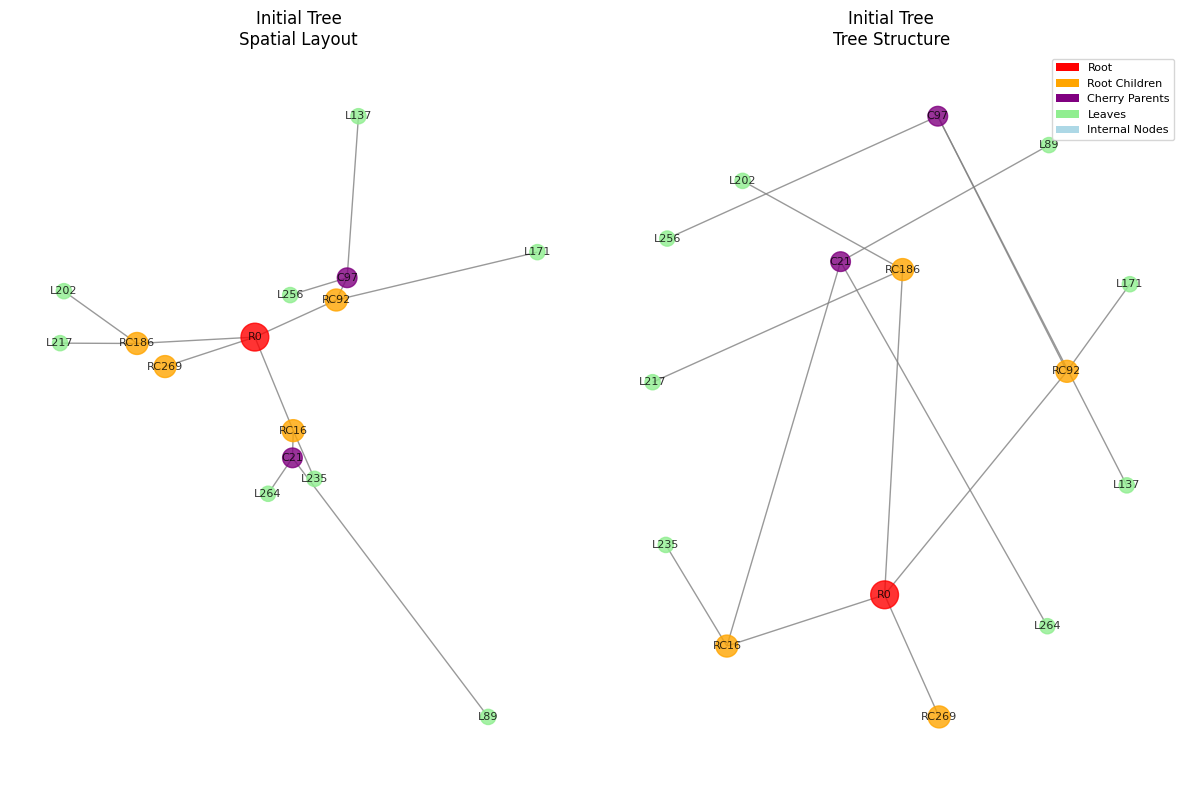

Initial Tree Statistics:
  Remaining nodes: 15
  Root: 0
  Root children: 4
  Current leaves: 9
  Available cherries: 3
  Cherry parents: [21, 97, 186]
--------------------------------------------------

🚀 Running EVENT-DRIVEN stochastic cherry reduction...
Choose reduction method:
  [1] Stochastic (p=0.8) with step-by-step visualization
  [2] Deterministic (all cherries per round) - faster

Running stochastic reduction with p=0.8...

Round 1: 3 cherries available
  Current state: 15 nodes, 9 leaves
    Cherry 1: 97 -> [137, 256]
    Cherry 2: 186 -> [202, 217]
    Cherry 3: 21 -> [89, 264]
  Selected 3 cherries for removal:
    Removing cherry: 97 -> [137, 256]
    Removing cherry: 186 -> [202, 217]
    Removing cherry: 21 -> [89, 264]
  Total leaf nodes to remove: 6


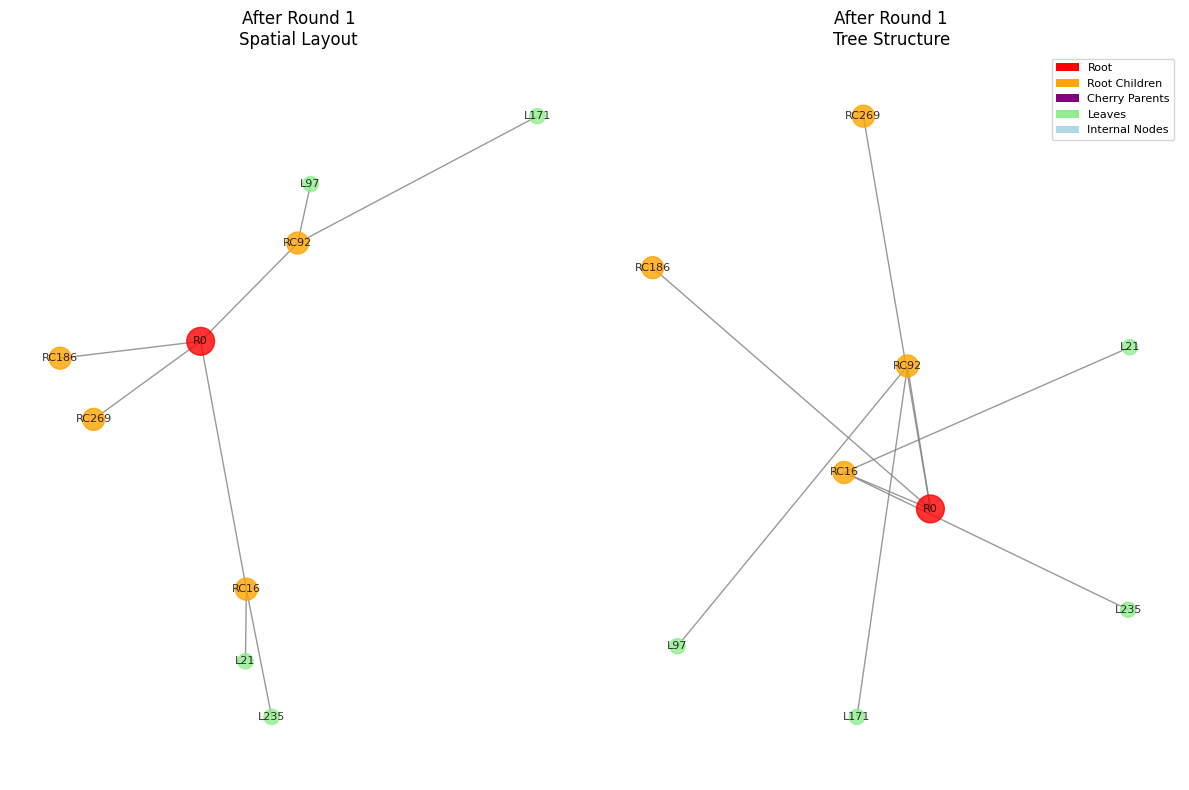

After Round 1 Statistics:
  Remaining nodes: 9
  Root: 0
  Root children: 4
  Current leaves: 6
  Available cherries: 2
  Cherry parents: [16, 92]
--------------------------------------------------

Round 2: 2 cherries available
  Current state: 9 nodes, 6 leaves
    Cherry 1: 16 -> [21, 235]
    Cherry 2: 92 -> [97, 171]
  Selected 2 cherries for removal:
    Removing cherry: 16 -> [21, 235]
    Removing cherry: 92 -> [97, 171]
  Total leaf nodes to remove: 4


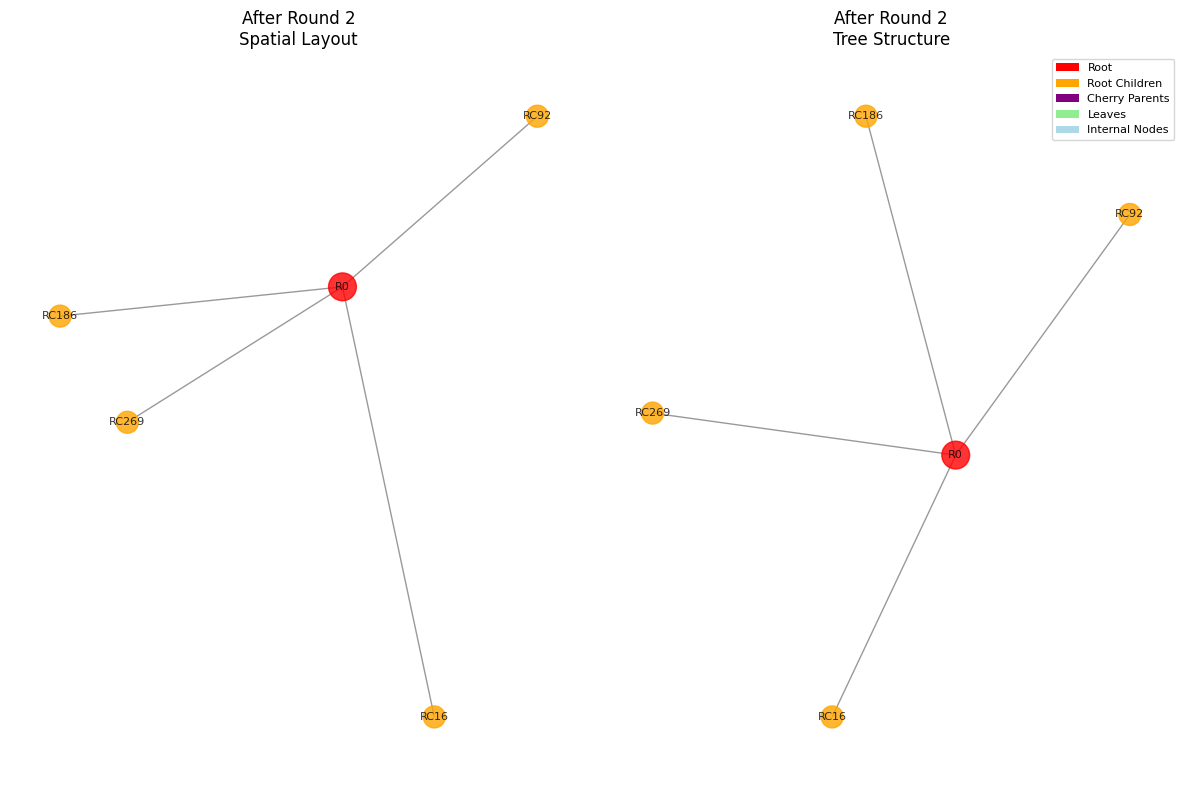

After Round 2 Statistics:
  Remaining nodes: 5
  Root: 0
  Root children: 4
  Current leaves: 4
  Available cherries: 1
  Cherry parents: [0]
--------------------------------------------------

Round 3: 1 cherries available
  Current state: 5 nodes, 4 leaves
    Cherry 1: 0 -> [16, 92, 186, 269]
  Selected 1 cherries for removal:
    Removing cherry: 0 -> [16, 92, 186, 269]
  Total leaf nodes to remove: 4


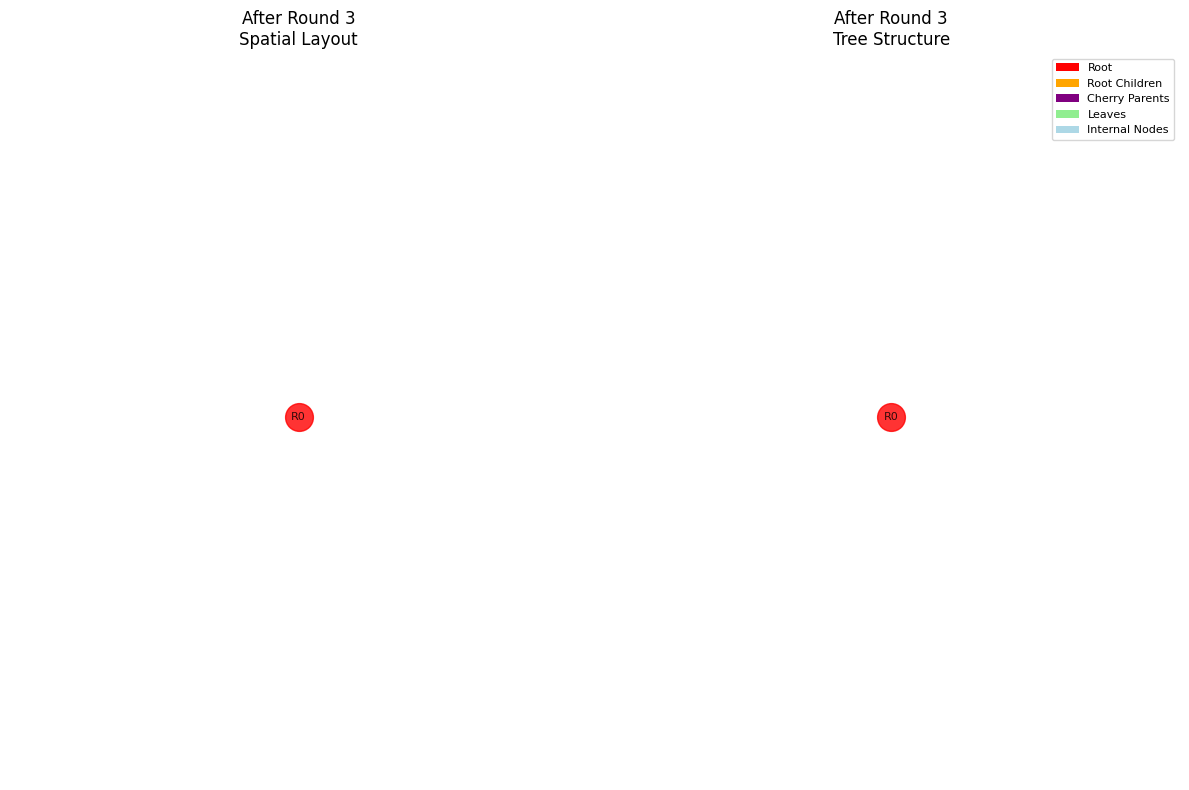

After Round 3 Statistics:
  Remaining nodes: 1
  Root: 0
  Root children: 4
  Current leaves: 0
  Available cherries: 0
  Cherry parents: []
--------------------------------------------------



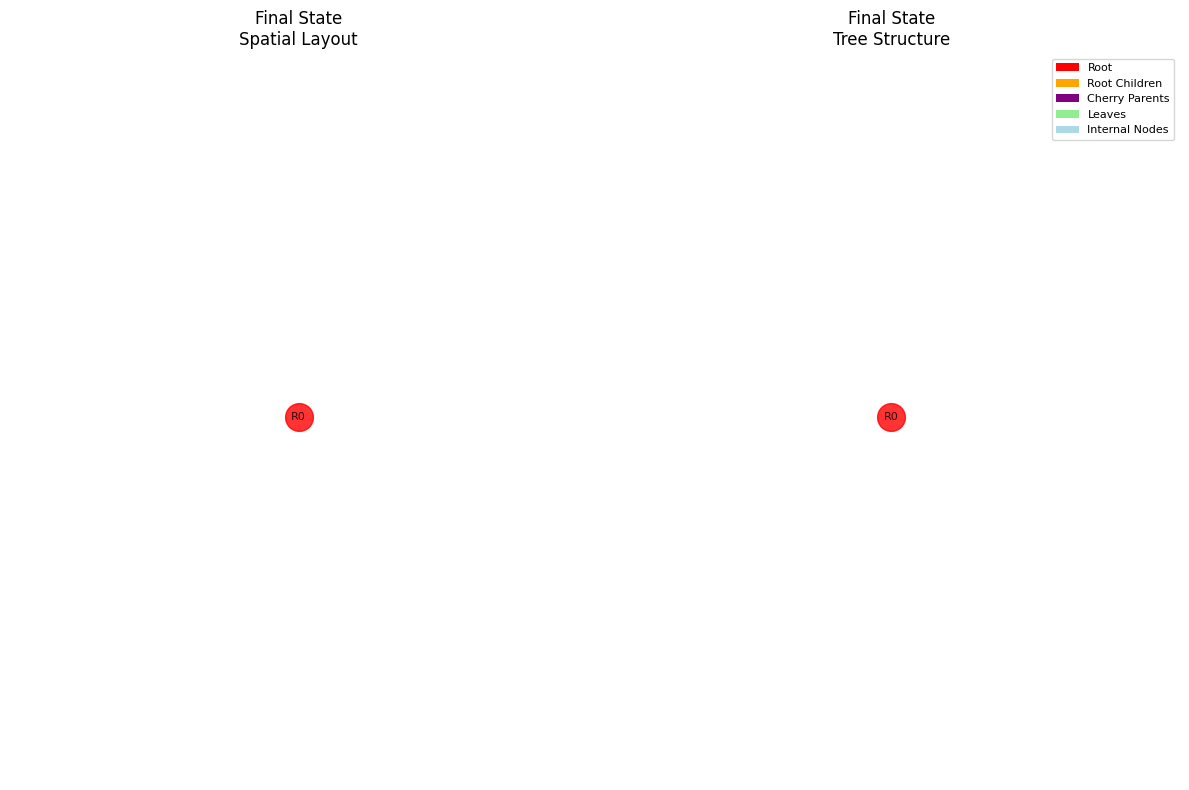

Final State Statistics:
  Remaining nodes: 1
  Root: 0
  Root children: 4
  Current leaves: 0
  Available cherries: 0
  Cherry parents: []
--------------------------------------------------

🎉 EVENT-DRIVEN REDUCTION COMPLETED! 🎉
Total rounds: 3
Total cherries removed: 6
Total leaf nodes removed: 14

Final state:
  Remaining nodes: 1
  Root: 0
  Root children: [16, 92, 186, 269] (original)
  Other nodes: []
  Final leaves: []

Verification:
  Expected final nodes: 1 (only root)
  Actual final nodes: 1
  ✅ Reduction successful!
  🎯 Perfect! Tree reduced to single root node: 0

📊 Performance Summary:
  Algorithm: Event-driven cherry reduction (stochastic)
  Time complexity: O(n/p) expected rounds, O(n) total work
  Memory: O(n) with incremental updates


In [82]:
# ENHANCED CHERRY REDUCTION WITH EVENT-DRIVEN VISUALIZATION

# Convert NetworkX graph to adjacency dictionary format expected by WorkingCherryReducer
adj_dict = {node: set(G.neighbors(node)) for node in G.nodes()}

# Check what nodes are available and find the root
print("Available nodes in graph G:", list(G.nodes()))
print("Node kinds:", {node: G.nodes[node]['kind'] for node in G.nodes()})

# Find the actual root node (the one with kind='root')
root_node = None
for node in G.nodes():
    if G.nodes[node]['kind'] == 'root':
        root_node = node
        break

print(f"Found root node: {root_node}")

if root_node is None:
    print("No root node found! Using the first node as root.")
    root_node = list(G.nodes())[0]

print(f"\nInitializing Event-Driven WorkingCherryReducer...")
reducer = WorkingCherryReducer(adj_dict, root=root_node, rng=random.Random(42))

# Plot initial state
print("\n" + "="*60)
plot_reduction_stage_event_driven(reducer, G, "Initial Tree")

# Option 1: Run stochastic reduction with step-by-step visualization
print(f"\n🚀 Running EVENT-DRIVEN stochastic cherry reduction...")
print(f"Choose reduction method:")
print(f"  [1] Stochastic (p=0.8) with step-by-step visualization")
print(f"  [2] Deterministic (all cherries per round) - faster")

# For now, let's use stochastic with visualization
use_stochastic = True
p = 0.8

if use_stochastic:
    print(f"\nRunning stochastic reduction with p={p}...")
    layers = []
    round_number = 0
    
    while reducer.current_cherries:  # Use the maintained cherry set
        round_number += 1
        
        # Get current state efficiently
        stats = reducer.get_reduction_stats()
        cherries_all = list(reducer.current_cherries)
        
        print(f"\nRound {round_number}: {stats['available_cherries']} cherries available")
        print(f"  Current state: {stats['remaining_nodes']} nodes, {stats['leaves']} leaves")
        
        # Show cherries if not too many
        if len(cherries_all) <= 10:
            for i, parent in enumerate(cherries_all, 1):
                children = list(reducer.children[parent])
                print(f"    Cherry {i}: {parent} -> {sorted(children)}")
        
        # Apply stochastic selection (Bernoulli(p) per cherry parent)
        chosen_parents = [u for u in cherries_all if reducer.rng.random() < p]
        if not chosen_parents:
            # Guarantee progress
            chosen_parents = [reducer.rng.choice(cherries_all)]
        
        chosen_tuples = [(u, list(reducer.children[u])) for u in chosen_parents]
        
        print(f"  Selected {len(chosen_tuples)} cherries for removal:")
        total_nodes_to_remove = 0
        for parent, children in chosen_tuples:
            total_nodes_to_remove += len(children)
            print(f"    Removing cherry: {parent} -> {sorted(children)}")
        
        print(f"  Total leaf nodes to remove: {total_nodes_to_remove}")
        
        # Create and apply the layer using event-driven method
        layer = CherryLayer(cherries=chosen_tuples)
        layers.append(layer)
        reducer._apply_layer_event_driven(layer, chosen_parents_set=set(chosen_parents))
        
        # Plot every few rounds or when nearing completion
        remaining_nodes = len(reducer._nodes)
        if (round_number <= 3 or round_number % 5 == 0 or 
            remaining_nodes <= 20 or len(reducer.current_cherries) <= 5):
            plot_reduction_stage_event_driven(reducer, G, f"After Round {round_number}")

else:
    # Deterministic version - remove all cherries each round
    print(f"\nRunning deterministic reduction...")
    layers = reducer.run_deterministic()

# Plot final state
print("\n" + "="*60)
plot_reduction_stage_event_driven(reducer, G, "Final State")

# Create the complete sequence and summary
seq_sto = CherrySequence(layers=layers)
final_stats = reducer.get_reduction_stats()

print(f"\n🎉 EVENT-DRIVEN REDUCTION COMPLETED! 🎉")
print(f"Total rounds: {len(seq_sto.layers)}")
print(f"Total cherries removed: {sum(len(layer.cherries) for layer in seq_sto.layers)}")
print(f"Total leaf nodes removed: {sum(sum(len(children) for _, children in layer.cherries) for layer in seq_sto.layers)}")
print(f"\nFinal state:")
print(f"  Remaining nodes: {final_stats['remaining_nodes']}")
print(f"  Root: {reducer.root}")
print(f"  Root children: {sorted(reducer.root_children)} (original)")
remaining_other = reducer._nodes - {reducer.root} - reducer.root_children
print(f"  Other nodes: {sorted(remaining_other)}")
print(f"  Final leaves: {sorted(reducer.leaves)}")

# Verification - expect only the root to remain
expected_final_nodes = 1  # Just the root
actual_final_nodes = len(reducer._nodes)
print(f"\nVerification:")
print(f"  Expected final nodes: {expected_final_nodes} (only root)")
print(f"  Actual final nodes: {actual_final_nodes}")
print(f"  ✅ Reduction successful!" if actual_final_nodes == expected_final_nodes else "❌ Unexpected final state")

if actual_final_nodes == 1:
    print(f"  🎯 Perfect! Tree reduced to single root node: {reducer.root}")
else:
    print(f"  🔍 Remaining nodes: {sorted(reducer._nodes)}")
    print(f"  📊 This means {actual_final_nodes - 1} additional node(s) besides root")

# Performance summary
print(f"\n📊 Performance Summary:")
print(f"  Algorithm: Event-driven cherry reduction ({'stochastic' if use_stochastic else 'deterministic'})")
print(f"  Time complexity: O(n/p) expected rounds, O(n) total work" if use_stochastic else "  Time complexity: O(n) total")
print(f"  Memory: O(n) with incremental updates")

In [81]:
# ALTERNATIVE: Quick verification without plots (for large trees)
print(f"\n🔧 Quick Verification Mode (no plots):")
print(f"If you want to skip plotting and just verify the reduction works:")

# Reinitialize for quick test
reducer_test = WorkingCherryReducer(adj_dict, root=root_node, rng=random.Random(123))

print(f"\nInitial verification:")
verify_reduction_progress(reducer_test, "Initial State")

# Run deterministic reduction (fastest)
print(f"\nRunning deterministic reduction...")
layers_test = reducer_test.run_deterministic()

print(f"\nFinal verification:")
verify_reduction_progress(reducer_test, "Final State")

# Analyze the complete sequence
analysis = analyze_reduction_sequence(layers_test, reducer_test)

print(f"\n✅ Quick verification complete!")
print(f"   Tree successfully reduced from {analysis['total_nodes_removed'] + analysis['final_nodes']} to {analysis['final_nodes']} nodes")
print(f"   Reduction efficiency: {analysis['reduction_ratio']:.1%} of nodes removed")


🔧 Quick Verification Mode (no plots):
If you want to skip plotting and just verify the reduction works:
Root has 4 children: [16, 92, 186, 269]
Initial leaves: 9 -> [89, 137, 171, 202, 217, 235, 256, 264, 269]
Initial cherries: 3 -> [21, 97, 186]

Initial verification:

📊 Initial State Verification:
  Remaining nodes: 15
  Leaves: 9
  Available cherries: 3
  Can continue: True
  State consistency:
    Leaves count matches: True
    Cherries count matches: True
  Remaining nodes: [0, 16, 21, 89, 92, 97, 137, 171, 186, 202, 217, 235, 256, 264, 269]
  Leaves: [89, 137, 171, 202, 217, 235, 256, 264, 269]
  Cherry parents: [21, 97, 186]
  Cherry details:
    21 -> [89, 264]
    97 -> [137, 256]
    186 -> [202, 217]
----------------------------------------

Running deterministic reduction...
Round 1: 3 cherries available, removing 3
  Removing 6 leaf nodes
    Cherry: 97 -> [137, 256]
    Cherry: 186 -> [202, 217]
    Cherry: 21 -> [89, 264]
  Remaining: 9 nodes, 6 leaves, 2 cherries
Round

In [ ]:
def plot_reduction_stage_event_driven(reducer, G_original, stage_name="", figsize=(12, 8)):
    """
    Plot the current state of the tree during reduction for the event-driven reducer.
    
    Parameters:
    -----------
    reducer : WorkingCherryReducer (event-driven version)
        The reducer object with current tree state
    G_original : networkx.Graph  
        Original graph for node positions and attributes
    stage_name : str
        Name/description of current stage
    figsize : tuple
        Figure size for the plot
    """
    import matplotlib.pyplot as plt
    import networkx as nx
    
    # Create a subgraph with only remaining nodes
    remaining_nodes = list(reducer._nodes)
    if not remaining_nodes:
        print(f"{stage_name}: No nodes remaining")
        return
        
    # Build current graph structure from reducer's internal state
    G_current = nx.Graph()
    
    # Add nodes with original attributes if they still exist
    for node in remaining_nodes:
        if node in G_original:
            G_current.add_node(node, **G_original.nodes[node])
        else:
            # Fallback for nodes not in original (shouldn't happen)
            G_current.add_node(node)
    
    # Add edges based on current adjacency
    for u in remaining_nodes:
        if u in reducer._adj:
            for v in reducer._adj[u]:
                if v in remaining_nodes and not G_current.has_edge(u, v):
                    G_current.add_edge(u, v)
    
    # Set up the plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Prepare node colors and sizes
    node_colors = []
    node_sizes = []
    node_labels = {}
    
    for node in G_current.nodes():
        # Determine node type and color
        if node == reducer.root:
            node_colors.append('red')
            node_sizes.append(400)
            node_labels[node] = f"R{node}"
        elif node in reducer.root_children:
            node_colors.append('orange') 
            node_sizes.append(250)
            node_labels[node] = f"RC{node}"
        elif node in reducer.current_cherries:
            node_colors.append('purple')  # Cherry parents - ready to be processed
            node_sizes.append(200)
            node_labels[node] = f"C{node}"
        elif node in reducer.leaves:
            node_colors.append('lightgreen')
            node_sizes.append(120)
            node_labels[node] = f"L{node}"
        else:
            node_colors.append('lightblue')
            node_sizes.append(180)
            node_labels[node] = str(node)
    
    # Plot 1: Spatial layout (if position info available)
    pos_spatial = {}
    for node in G_current.nodes():
        if 'pos' in G_current.nodes[node]:
            pos_spatial[node] = (G_current.nodes[node]['pos'][2], G_current.nodes[node]['pos'][1])
        else:
            pos_spatial[node] = (0, 0)  # fallback
    
    if pos_spatial:
        nx.draw(G_current, pos_spatial, ax=ax1,
                node_color=node_colors,
                node_size=node_sizes,
                labels=node_labels,
                font_size=8,
                edge_color='gray',
                alpha=0.8)
        ax1.set_title(f'{stage_name}\nSpatial Layout')
        ax1.set_xlabel('Z (nm)')
        ax1.set_ylabel('Y (nm)')
    
    # Plot 2: Tree layout 
    if len(G_current.nodes()) > 0:
        pos_tree = nx.spring_layout(G_current, k=2, iterations=50)
        nx.draw(G_current, pos_tree, ax=ax2,
                node_color=node_colors,
                node_size=node_sizes,
                labels=node_labels,
                font_size=8,
                edge_color='gray',
                alpha=0.8)
    
    ax2.set_title(f'{stage_name}\nTree Structure')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', label='Root'),
        Patch(facecolor='orange', label='Root Children'),
        Patch(facecolor='purple', label='Cherry Parents'),
        Patch(facecolor='lightgreen', label='Leaves'),
        Patch(facecolor='lightblue', label='Internal Nodes')
    ]
    ax2.legend(handles=legend_elements, loc='upper right', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics using event-driven state
    print(f"{stage_name} Statistics:")
    print(f"  Remaining nodes: {len(remaining_nodes)}")
    print(f"  Root: {reducer.root}")
    print(f"  Root children: {len(reducer.root_children)}")
    print(f"  Current leaves: {len(reducer.leaves)}")
    print(f"  Available cherries: {len(reducer.current_cherries)}")
    print(f"  Cherry parents: {sorted(reducer.current_cherries)}")
    print("-" * 50)


def verify_reduction_progress(reducer, stage_name=""):
    """
    Verify and display the reduction progress without plotting (lightweight).
    
    Parameters:
    -----------
    reducer : WorkingCherryReducer
        The event-driven reducer object
    stage_name : str
        Name/description of current stage
    """
    stats = reducer.get_reduction_stats()
    
    print(f"\n📊 {stage_name} Verification:")
    print(f"  Remaining nodes: {stats['remaining_nodes']}")
    print(f"  Leaves: {stats['leaves']}")
    print(f"  Available cherries: {stats['available_cherries']}")
    print(f"  Can continue: {stats['can_continue']}")
    
    # Check consistency
    actual_leaves = len(reducer.leaves)
    actual_cherries = len(reducer.current_cherries)
    
    print(f"  State consistency:")
    print(f"    Leaves count matches: {actual_leaves == stats['leaves']}")
    print(f"    Cherries count matches: {actual_cherries == stats['available_cherries']}")
    
    # Show specific nodes if small enough
    if stats['remaining_nodes'] <= 20:
        print(f"  Remaining nodes: {sorted(reducer._nodes)}")
        print(f"  Leaves: {sorted(reducer.leaves)}")
        print(f"  Cherry parents: {sorted(reducer.current_cherries)}")
        
        # Show cherry structure
        if reducer.current_cherries:
            print(f"  Cherry details:")
            for parent in sorted(reducer.current_cherries):
                children = sorted(reducer.children[parent])
                print(f"    {parent} -> {children}")
    
    print("-" * 40)


def analyze_reduction_sequence(layers, reducer):
    """
    Analyze the complete reduction sequence.
    
    Parameters:
    -----------
    layers : List[CherryLayer]
        The sequence of reduction layers
    reducer : WorkingCherryReducer
        The final reducer state
    """
    print(f"\n🔍 REDUCTION SEQUENCE ANALYSIS:")
    print(f"=" * 50)
    
    total_nodes_removed = 0
    total_cherries_removed = 0
    
    for i, layer in enumerate(layers, 1):
        layer_nodes = sum(len(children) for _, children in layer.cherries)
        layer_cherries = len(layer.cherries)
        
        total_nodes_removed += layer_nodes
        total_cherries_removed += layer_cherries
        
        print(f"Round {i}:")
        print(f"  Cherries removed: {layer_cherries}")
        print(f"  Leaf nodes removed: {layer_nodes}")
        print(f"  Cumulative nodes removed: {total_nodes_removed}")
        
        # Show details for first few rounds
        if i <= 3:
            print(f"  Details:")
            for parent, children in layer.cherries:
                print(f"    {parent} -> {sorted(children)}")
        elif i == 4 and len(layers) > 3:
            print(f"  (Details omitted for remaining rounds...)")
        
        print()
    
    print(f"📈 Summary Statistics:")
    print(f"  Total rounds: {len(layers)}")
    print(f"  Total cherries processed: {total_cherries_removed}")
    print(f"  Total leaf nodes removed: {total_nodes_removed}")
    print(f"  Final remaining nodes: {len(reducer._nodes)}")
    print(f"  Reduction ratio: {total_nodes_removed}/{total_nodes_removed + len(reducer._nodes)} = {total_nodes_removed/(total_nodes_removed + len(reducer._nodes)):.1%}")
    
    return {
        'total_rounds': len(layers),
        'total_cherries': total_cherries_removed,
        'total_nodes_removed': total_nodes_removed,
        'final_nodes': len(reducer._nodes),
        'reduction_ratio': total_nodes_removed/(total_nodes_removed + len(reducer._nodes))
    }

In [79]:
def plot_cherry_removal(reducer, G_original, cherries_to_remove, stage_name="", figsize=(10, 8)):
    """
    Plot the tree highlighting the cherries that will be removed in this round.
    
    Parameters:
    -----------
    reducer : CherryReducer
        The reducer object with current tree state
    G_original : networkx.Graph  
        Original graph for node positions and attributes
    cherries_to_remove : list
        List of (parent, child1, child2) tuples to be removed
    stage_name : str
        Name/description of current stage
    """
    import matplotlib.pyplot as plt
    import networkx as nx
    
    # Create current graph
    remaining_nodes = list(reducer._nodes)
    if not remaining_nodes:
        return
        
    G_current = nx.Graph()
    
    # Add nodes
    for node in remaining_nodes:
        if node in G_original:
            G_current.add_node(node, **G_original.nodes[node])
        else:
            G_current.add_node(node)
    
    # Add edges
    for u in remaining_nodes:
        if u in reducer._adj:
            for v in reducer._adj[u]:
                if v in remaining_nodes and not G_current.has_edge(u, v):
                    G_current.add_edge(u, v)
    
    # Identify nodes to be removed
    nodes_to_remove = set()
    cherry_parents = set()
    for parent, child1, child2 in cherries_to_remove:
        nodes_to_remove.add(child1)
        nodes_to_remove.add(child2)
        cherry_parents.add(parent)
    
    # Set up colors and sizes
    node_colors = []
    node_sizes = []
    node_labels = {}
    
    for node in G_current.nodes():
        if node in nodes_to_remove:
            node_colors.append('red')  # Nodes being removed
            node_sizes.append(200)
            node_labels[node] = f"X{node}"
        elif node in cherry_parents:
            node_colors.append('purple')  # Cherry parents (will become leaves)
            node_sizes.append(300)
            node_labels[node] = f"P{node}"
        elif node == reducer.root:
            node_colors.append('darkred')
            node_sizes.append(400)
            node_labels[node] = f"R{node}"
        elif node in reducer.root_children:
            node_colors.append('orange')
            node_sizes.append(250)
            node_labels[node] = f"RC{node}"
        elif node in reducer.leaves:
            node_colors.append('lightgreen')
            node_sizes.append(120)
            node_labels[node] = f"L{node}"
        else:
            node_colors.append('lightblue')
            node_sizes.append(180)
            node_labels[node] = str(node)
    
    # Create layout
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    pos = nx.spring_layout(G_current, k=2, iterations=50)
    nx.draw(G_current, pos, ax=ax,
            node_color=node_colors,
            node_size=node_sizes,
            labels=node_labels,
            font_size=8,
            edge_color='gray',
            alpha=0.8)
    
    # Highlight cherry edges in red
    cherry_edges = []
    for parent, child1, child2 in cherries_to_remove:
        if G_current.has_edge(parent, child1):
            cherry_edges.append((parent, child1))
        if G_current.has_edge(parent, child2):
            cherry_edges.append((parent, child2))
    
    if cherry_edges:
        nx.draw_networkx_edges(G_current, pos, edgelist=cherry_edges, 
                             edge_color='red', width=3, alpha=0.8, ax=ax)
    
    ax.set_title(f'{stage_name}\nRemoving {len(cherries_to_remove)} cherries')
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', label='Nodes to Remove'),
        Patch(facecolor='purple', label='Cherry Parents'),
        Patch(facecolor='darkred', label='Root'),
        Patch(facecolor='orange', label='Root Children'),
        Patch(facecolor='lightgreen', label='Current Leaves'),
        Patch(facecolor='lightblue', label='Internal Nodes')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
    
    plt.tight_layout()
    plt.show()


#### Plot skeleton

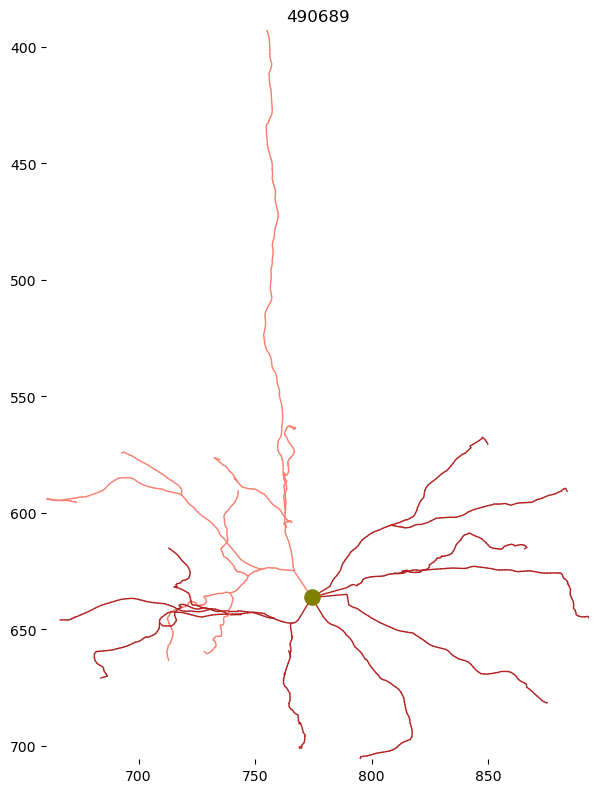

In [15]:
f, ax = plt.subplots(figsize=(7, 10))
skelplot.plot_tools.plot_skel(
    sk,
    title=nucleus_id,
    line_width=1,
    plot_soma=True,
    invert_y=True,
    pull_compartment_colors=True,
    x="z",
    y="y",
    skel_color_map = { 3: "firebrick",4: "salmon",2: "black",1: "olive" },
)

ax.spines['right'].set_visible(False) 
ax.spines['left'].set_visible(False) 
ax.spines['top'].set_visible(False) 
ax.spines['bottom'].set_visible(False)
# ax.axis('off')

Note that this skeleton has no axon compartment. That is because the axon has only been proofread after the skeleton was created. Non-proofread cells do not have their axon statistics generated.

### Example: querying the proofread cells

Cells that have undergone proofreading in the dataset are annotated in the `proofreading_status_and_strategy table`. For more information, [see the MICrONS-Explorer proofreading documentation](https://www.microns-explorer.org/manifests/mm3-proofreading)

In [16]:
# Load cells that have undergone proofreading
proof_df = client.materialize.tables.proofreading_status_and_strategy(status_axon=True).query(
    select_columns = ['pt_root_id','pt_position','status_dendrite','status_axon','strategy_dendrite','strategy_axon'],
    materialization_version=1078)

# This gives you the list of cells with axonal proofreading, anywhere in the dataset
proof_df.head()

Table Owner Notice on proofreading_status_and_strategy: NOTE: this table supercedes 'proofreading_status_public_release'. For more details, see: www.microns-explorer.org/manifests/mm3-proofreading.


,pt_root_id,status_dendrite,status_axon,strategy_dendrite,strategy_axon,pt_position
0,864691135617152361,t,t,dendrite_extended,axon_partially_extended,"[185152, 185344, 21255]"
1,864691136090326071,t,t,dendrite_extended,axon_fully_extended,"[192080, 190064, 22297]"
2,864691135082864887,t,t,dendrite_extended,axon_interareal,"[303659, 166262, 17349]"
3,864691136195284556,t,t,dendrite_extended,axon_fully_extended,"[173184, 217472, 21929]"
4,864691135565870679,t,t,dendrite_clean,axon_fully_extended,"[184384, 108896, 21755]"


**Note: for v661,** the current preferred proofreading table did not exist. Use `proofreading_status_public_release` instead

In [17]:
# Load cells that have underwent proofreading for v661
proof_df = client.materialize.tables.proofreading_status_public_release().query(
    select_columns = ['pt_root_id','pt_position','status_dendrite','status_axon'],
    materialization_version=661)

# This gives you the list of cells with axonal proofreading, anywhere in the dataset
proof_df.head()

Table Owner Notice on proofreading_status_public_release: NOTE: this table is deprecated and no longer receiving updates; please use 'proofreading_status_and_strategy' which is available in datastack version >= 1078 (datastack = minnie65_public or minnie65_phase3_v1).


,pt_root_id,status_dendrite,status_axon,pt_position
0,864691134884807418,extended,extended,"[299067, 123129, 22993]"
1,864691134885430010,extended,non,"[181280, 223040, 21399]"
2,864691134885645050,extended,non,"[172288, 222528, 21607]"
3,864691134918370314,clean,clean,"[170528, 226848, 20316]"
4,864691134918461194,clean,clean,"[189760, 127520, 20540]"


### Final example: generate skeletons with pcg_skel
This will let you create skeletons for more recently proofread cells that do not exist in the publicly pregenerated .swc files. However, these skeletons will come without apical dendrite labels 

[pcg-skel documentation](https://caveconnectome.github.io/pcg_skel/) 


In [18]:
# !pip install pcg-skel
# !pip install cloud-volume

In [19]:
import cloudvolume
import pcg_skel

# specify the materialization version
client.materialize.version = 1078

# initialize cloudvolume client
cv_minnie = cloudvolume.CloudVolume(client.info.segmentation_source(), use_https=True)

In [20]:
# pcg-skel pipeline code
input_id = 864691135639556411
id_is_nuc = False

# Cell identification meta
synapse_table = client.info.get_datastack_info()['synapse_table']
if id_is_nuc:
    id_col = 'id'
else:
    id_col = 'pt_root_id'
use_view = True
if use_view:
    row = client.materialize.query_view('nucleus_detection_lookup_v1', 
                filter_equal_dict = {id_col: input_id})
else:
    row = client.materialize.query_table('nucleus_detection_v0', 
                filter_equal_dict = {id_col: input_id})
    
    row = row.drop('created', axis = 1)

nuc_id = int(row['id']) 
root_id = int(row['pt_root_id'])
root_point = row['pt_position'].values[0]

print(f'starting on body {nuc_id}, {root_id}')

# create whole neuron with radius info
resample_spacing = 1510
collapse_soma = True
collapse_radius = 10_000
res = [4, 4, 40]
nrn =  pcg_skel.coord_space_meshwork(root_id,
                                     client=client,
                                     root_point=root_point,
                                     root_point_resolution=res,
                                     collapse_soma=collapse_soma,
                                     collapse_radius=collapse_radius,
                                     synapses='all',
                                     synapse_table=synapse_table,
                                     cv = cv_minnie)

# add radius properties df to annotations 
pcg_skel.features.add_volumetric_properties(nrn, client)
print('adding segment properties')
pcg_skel.features.add_segment_properties(nrn)
print('segment properties added')

starting on body 267207, 864691135639556411
adding segment properties
segment properties added


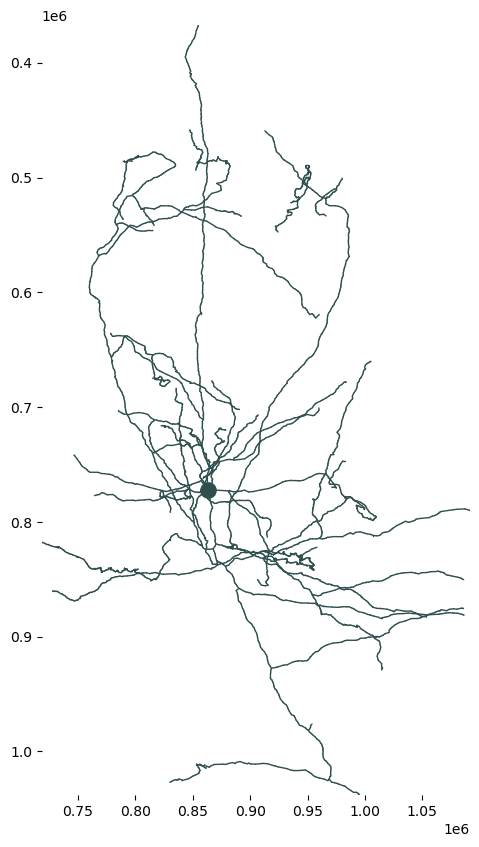

In [21]:
f, ax = plt.subplots(figsize=(7, 10))

skelplot.plot_tools.plot_verts(nrn.skeleton.vertices, 
                               nrn.skeleton.edges, 
                               nrn.skeleton.radius,
                               plot_soma=True,
                               soma_node=nrn.skeleton.root,
                               x="z",
                               y="y")

ax.spines['right'].set_visible(False) 
ax.spines['left'].set_visible(False) 
ax.spines['top'].set_visible(False) 
ax.spines['bottom'].set_visible(False)
plt.gca().invert_yaxis()

#### Save SWC file

In [22]:
# create compartment label
compartment_labels = np.zeros(len(nrn.skeleton.vertices)).astype(int)

# add soma label
compartment_labels[int(nrn.skeleton.root)]=1

# get the mesh volume properties
volume_df = nrn.anno.segment_properties.df

# add column indicating skel index 
volume_df['skel_index'] = nrn.anno.segment_properties.mesh_index.to_skel_index_padded
sk_volume_df = volume_df.drop_duplicates('skel_index').sort_values('skel_index').reset_index()

# set map for skel index -> radius
radius_labels = np.array(sk_volume_df['r_eff']) / 1000

# metadata dictionary for keeping vertex variables together
skeleton_properties = {}
skeleton_properties['compartment'] = compartment_labels
skeleton_properties['vertices'] = nrn.skeleton.vertices
skeleton_properties['edges'] = nrn.skeleton.edges
skeleton_properties['radius'] = radius_labels

In [23]:
nrn.skeleton.export_to_swc(filename = 'test.swc', 
                           node_labels=compartment_labels, 
                           radius=radius_labels,
                           avoid_root=True, 
                           resample_spacing = resample_spacing)